# Gradient Descent for Linear Regression with PyTorch

This notebook follows the structure of `C1_W1_Lab05_Gradient_Descent_Soln.ipynb`, but rewrites the implementation with PyTorch tensors and autograd.

## Goals
- represent the training data with PyTorch tensors
- implement the linear regression cost function
- compare manual gradients with `autograd`
- learn `w` and `b` with gradient descent
- visualize convergence and divergence


## Tools

This notebook uses:
- `torch` for tensor computation and automatic differentiation
- `matplotlib` for visualization
- `numpy` for contour-grid generation


In [29]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch

plt.style.use('./deeplearning.mplstyle')
torch.set_default_dtype(torch.float32)


## Problem Statement

We use the same simple housing dataset from the original Week 1 lab:
- `x`: house size in 1000 square feet
- `y`: house price in 1000 dollars

We want to fit the linear model

$$f_{w,b}(x) = wx + b$$

and use gradient descent to automatically find good values for `w` and `b`.


x_train = tensor([1., 2.])
y_train = tensor([300., 500.])
shape of x_train: (2,)
shape of y_train: (2,)


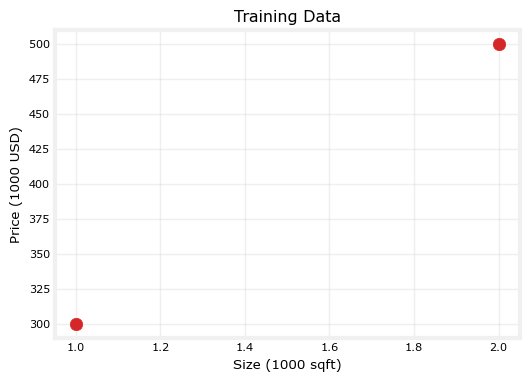

In [30]:
x_train = torch.tensor([1.0, 2.0])
y_train = torch.tensor([300.0, 500.0])

print(f'x_train = {x_train}')
print(f'y_train = {y_train}')
print(f'shape of x_train: {tuple(x_train.shape)}')
print(f'shape of y_train: {tuple(y_train.shape)}')

plt.figure(figsize=(6, 4))
plt.scatter(x_train.numpy(), y_train.numpy(), color='tab:red', s=80)
plt.title('Training Data')
plt.xlabel('Size (1000 sqft)')
plt.ylabel('Price (1000 USD)')
plt.grid(True, alpha=0.3)
plt.show()


## Compute Cost

For linear regression, the squared-error cost is

$$J(w, b) = \\frac{1}{2m} \\sum_{i=0}^{m-1}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$

We implement it below with vectorized PyTorch operations.


In [31]:
def compute_cost(x, y, w, b):
    predictions = w * x + b
    return ((predictions - y) ** 2).mean() / 2

w_test = torch.tensor(200.0)
b_test = torch.tensor(100.0)
print(f'Cost at w=200, b=100: {compute_cost(x_train, y_train, w_test, b_test).item():.4f}')

w_zero = torch.tensor(0.0)
b_zero = torch.tensor(0.0)
print(f'Cost at w=0, b=0: {compute_cost(x_train, y_train, w_zero, b_zero).item():.4f}')


Cost at w=200, b=100: 0.0000
Cost at w=0, b=0: 85000.0000


## Gradient Descent Summary

The update rules are

$$
\\begin{aligned}
w &:= w - \\alpha \\frac{\\partial J(w,b)}{\\partial w} \\\\
b &:= b - \\alpha \\frac{\\partial J(w,b)}{\\partial b}
\\end{aligned}
$$

We first compute the gradients manually, then verify them with `autograd`.


In [32]:
def compute_gradient_manual(x, y, w, b):
    m = x.shape[0]
    predictions = w * x + b
    errors = predictions - y
    dj_dw = (errors * x).sum() / m
    dj_db = errors.sum() / m
    return dj_dw, dj_db

w_current = torch.tensor(0.0)
b_current = torch.tensor(0.0)
dj_dw, dj_db = compute_gradient_manual(x_train, y_train, w_current, b_current)
print(f'manual dj_dw: {dj_dw.item():.4f}')
print(f'manual dj_db: {dj_db.item():.4f}')


manual dj_dw: -650.0000
manual dj_db: -400.0000


In [33]:
def compute_gradient_autograd(x, y, w_value, b_value):
    w = torch.tensor(w_value, requires_grad=True)
    b = torch.tensor(b_value, requires_grad=True)
    cost = compute_cost(x, y, w, b)
    cost.backward()
    return cost.detach(), w.grad.detach(), b.grad.detach()

cost_value, auto_dj_dw, auto_dj_db = compute_gradient_autograd(x_train, y_train, 0.0, 0.0)
print(f'cost: {cost_value.item():.4f}')
print(f'autograd dj_dw: {auto_dj_dw.item():.4f}')
print(f'autograd dj_db: {auto_dj_db.item():.4f}')


cost: 85000.0000
autograd dj_dw: -650.0000
autograd dj_db: -400.0000


In [34]:
print('manual and autograd gradients match:')
print(f'dj_dw close: {torch.isclose(dj_dw, auto_dj_dw)}')
print(f'dj_db close: {torch.isclose(dj_db, auto_dj_db)}')


manual and autograd gradients match:
dj_dw close: True
dj_db close: True


## Implement Gradient Descent with PyTorch

This version uses automatic differentiation to update the parameters and stores the optimization history for plotting.


In [35]:
def gradient_descent_torch(x, y, w_in, b_in, alpha, num_iters):
    w = torch.tensor(float(w_in), requires_grad=True)
    b = torch.tensor(float(b_in), requires_grad=True)

    J_history = []
    p_history = []

    for i in range(num_iters):
        cost = compute_cost(x, y, w, b)
        cost.backward()

        with torch.no_grad():
            w -= alpha * w.grad
            b -= alpha * b.grad

        if i < 100000:
            J_history.append(compute_cost(x, y, w.detach(), b.detach()).item())
            p_history.append((w.detach().item(), b.detach().item()))

        if i % max(1, math.ceil(num_iters / 10)) == 0:
            print(
                f'Iteration {i:4d}: Cost {J_history[-1]:0.2e}, '
                f'dj_dw: {w.grad.item(): 0.3e}, dj_db: {b.grad.item(): 0.3e}, '
                f'w: {w.item(): 0.3e}, b: {b.item(): 0.3e}'
            )

        w.grad.zero_()
        b.grad.zero_()

    return w.detach(), b.detach(), J_history, p_history


In [36]:
w_init = 0.0
b_init = 0.0
iterations = 10_000
alpha = 1.0e-2

w_final, b_final, J_hist, p_hist = gradient_descent_torch(
    x_train, y_train, w_init, b_init, alpha, iterations
)

print(f'(w, b) found by gradient descent: ({w_final.item():.4f}, {b_final.item():.4f})')


Iteration    0: Cost 7.93e+04, dj_dw: -6.500e+02, dj_db: -4.000e+02, w:  6.500e+00, b:  4.000e+00
Iteration 1000: Cost 3.41e+00, dj_dw: -3.712e-01, dj_db:  6.006e-01, w:  1.949e+02, b:  1.082e+02
Iteration 2000: Cost 7.93e-01, dj_dw: -1.789e-01, dj_db:  2.896e-01, w:  1.975e+02, b:  1.040e+02
Iteration 3000: Cost 1.84e-01, dj_dw: -8.624e-02, dj_db:  1.396e-01, w:  1.988e+02, b:  1.019e+02
Iteration 4000: Cost 4.29e-02, dj_dw: -4.173e-02, dj_db:  6.723e-02, w:  1.994e+02, b:  1.009e+02
Iteration 5000: Cost 9.99e-03, dj_dw: -2.040e-02, dj_db:  3.230e-02, w:  1.997e+02, b:  1.004e+02
Iteration 6000: Cost 2.34e-03, dj_dw: -9.888e-03, dj_db:  1.562e-02, w:  1.999e+02, b:  1.002e+02
Iteration 7000: Cost 5.55e-04, dj_dw: -5.295e-03, dj_db:  7.309e-03, w:  1.999e+02, b:  1.001e+02
Iteration 8000: Cost 1.32e-04, dj_dw: -2.274e-03, dj_db:  3.754e-03, w:  2.000e+02, b:  1.001e+02
Iteration 9000: Cost 3.14e-05, dj_dw: -7.935e-04, dj_db:  2.029e-03, w:  2.000e+02, b:  1.000e+02
(w, b) found by grad

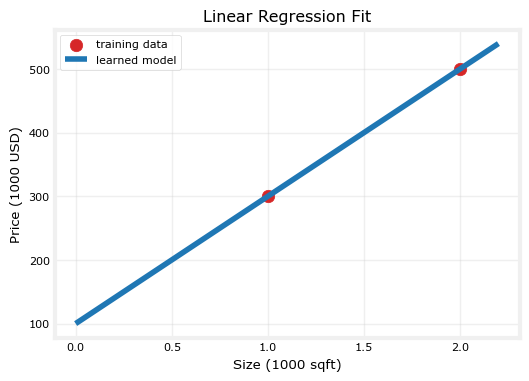

In [37]:
x_line = torch.linspace(0.0, 2.2, 100)
y_line = w_final * x_line + b_final

plt.figure(figsize=(6, 4))
plt.scatter(x_train.numpy(), y_train.numpy(), color='tab:red', s=80, label='training data')
plt.plot(x_line.numpy(), y_line.numpy(), color='tab:blue', label='learned model')
plt.xlabel('Size (1000 sqft)')
plt.ylabel('Price (1000 USD)')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


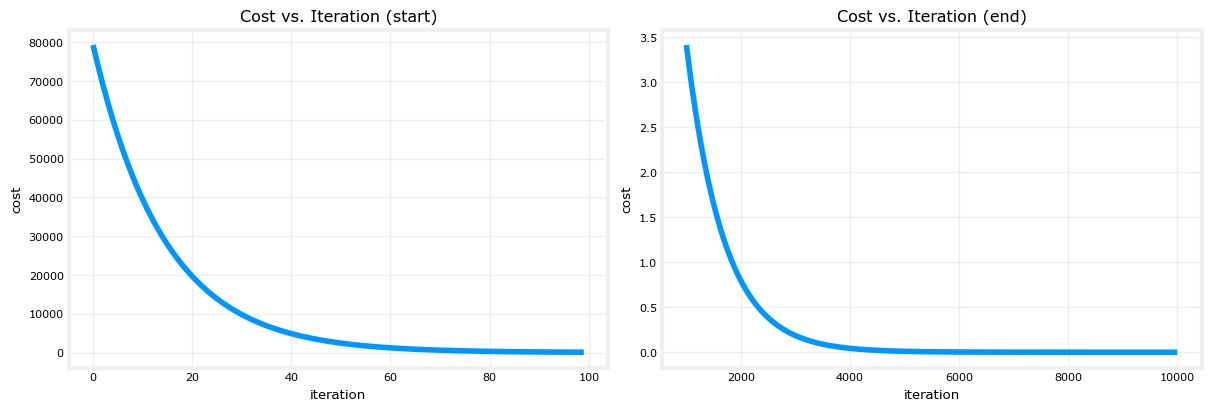

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ax1.plot(J_hist[:100])
ax1.set_title('Cost vs. Iteration (start)')
ax1.set_xlabel('iteration')
ax1.set_ylabel('cost')
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(1000, len(J_hist)), J_hist[1000:])
ax2.set_title('Cost vs. Iteration (end)')
ax2.set_xlabel('iteration')
ax2.set_ylabel('cost')
ax2.grid(True, alpha=0.3)
plt.show()


In [39]:
print(f'1000 sqft house prediction: {(w_final * 1.0 + b_final).item():0.1f} thousand dollars')
print(f'1200 sqft house prediction: {(w_final * 1.2 + b_final).item():0.1f} thousand dollars')
print(f'2000 sqft house prediction: {(w_final * 2.0 + b_final).item():0.1f} thousand dollars')


1000 sqft house prediction: 300.0 thousand dollars
1200 sqft house prediction: 340.0 thousand dollars
2000 sqft house prediction: 500.0 thousand dollars


## Cost Surface and Optimization Path

The contour plot below shows the cost surface in the `(w, b)` space together with the path taken by gradient descent.


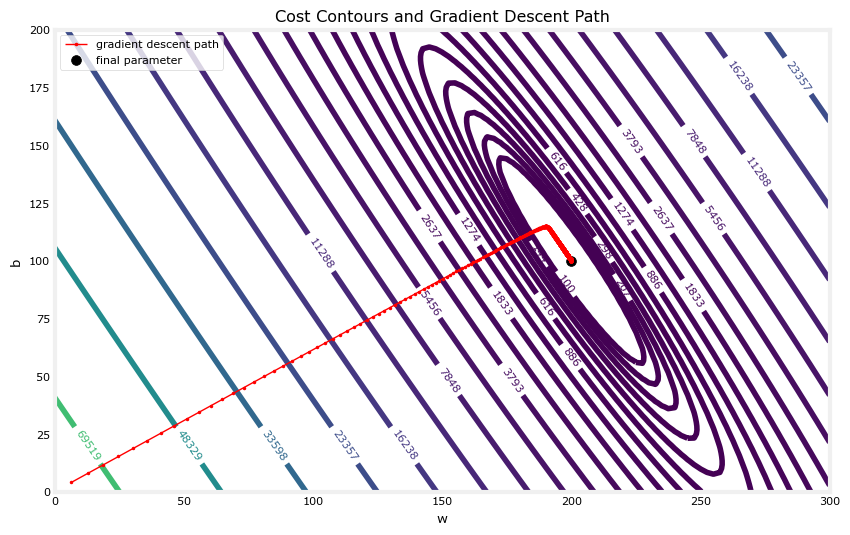

In [40]:
w_vals = np.linspace(0, 300, 121)
b_vals = np.linspace(0, 200, 121)
W, B = np.meshgrid(w_vals, b_vals)
Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i, j] = compute_cost(
            x_train,
            y_train,
            torch.tensor(W[i, j], dtype=torch.float32),
            torch.tensor(B[i, j], dtype=torch.float32),
        ).item()

path = np.array(p_hist)

plt.figure(figsize=(10, 6))
contours = plt.contour(W, B, Z, levels=np.logspace(2, 5, 20), cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)
plt.plot(path[:, 0], path[:, 1], 'r.-', markersize=3, linewidth=1, label='gradient descent path')
plt.scatter([w_final.item()], [b_final.item()], color='black', s=50, label='final parameter')
plt.xlabel('w')
plt.ylabel('b')
plt.title('Cost Contours and Gradient Descent Path')
plt.legend()
plt.show()


## Increased Learning Rate

If the learning rate is too large, the updates can overshoot the minimum and diverge.


In [41]:
large_alpha = 8.0e-1
div_iters = 10

w_div, b_div, J_hist_div, p_hist_div = gradient_descent_torch(
    x_train, y_train, 0.0, 0.0, large_alpha, div_iters
)

print(f'large-alpha result: w={w_div.item():.4f}, b={b_div.item():.4f}')


Iteration    0: Cost 2.58e+05, dj_dw: -6.500e+02, dj_db: -4.000e+02, w:  5.200e+02, b:  3.200e+02
Iteration    1: Cost 7.82e+05, dj_dw:  1.130e+03, dj_db:  7.000e+02, w: -3.840e+02, b: -2.400e+02
Iteration    2: Cost 2.37e+06, dj_dw: -1.970e+03, dj_db: -1.216e+03, w:  1.192e+03, b:  7.328e+02
Iteration    3: Cost 7.19e+06, dj_dw:  3.429e+03, dj_db:  2.121e+03, w: -1.551e+03, b: -9.638e+02
Iteration    4: Cost 2.18e+07, dj_dw: -5.974e+03, dj_db: -3.691e+03, w:  3.228e+03, b:  1.989e+03
Iteration    5: Cost 6.62e+07, dj_dw:  1.040e+04, dj_db:  6.431e+03, w: -5.095e+03, b: -3.156e+03
Iteration    6: Cost 2.01e+08, dj_dw: -1.812e+04, dj_db: -1.120e+04, w:  9.402e+03, b:  5.802e+03
Iteration    7: Cost 6.09e+08, dj_dw:  3.156e+04, dj_db:  1.950e+04, w: -1.584e+04, b: -9.801e+03
Iteration    8: Cost 1.85e+09, dj_dw: -5.496e+04, dj_db: -3.397e+04, w:  2.813e+04, b:  1.737e+04
Iteration    9: Cost 5.60e+09, dj_dw:  9.572e+04, dj_db:  5.916e+04, w: -4.845e+04, b: -2.996e+04
large-alpha result: 

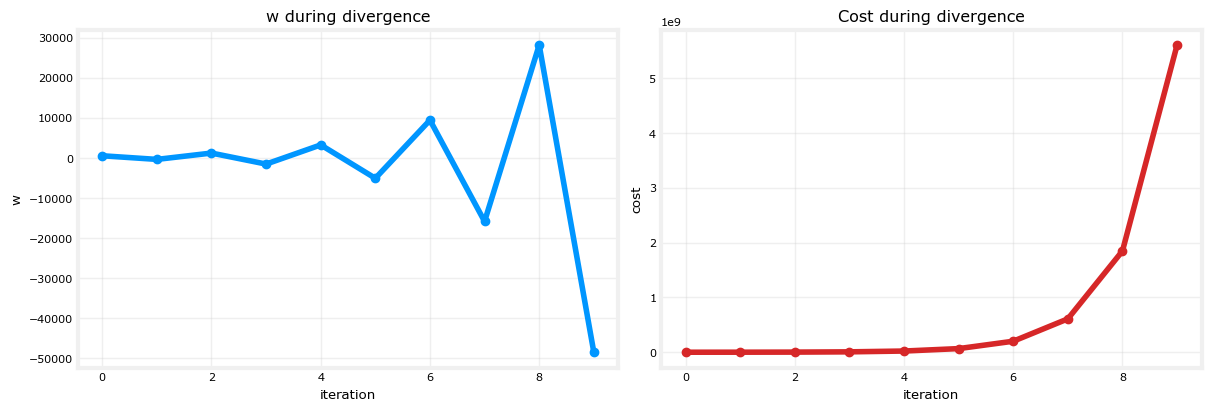

In [42]:
path_div = np.array(p_hist_div)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(path_div[:, 0], marker='o')
axes[0].set_title('w during divergence')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('w')
axes[0].grid(True, alpha=0.3)

axes[1].plot(J_hist_div, marker='o', color='tab:red')
axes[1].set_title('Cost during divergence')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('cost')
axes[1].grid(True, alpha=0.3)
plt.show()


## Summary

This PyTorch version recreates the key steps from the original lab:
- define the linear regression cost
- compute and verify gradients
- optimize parameters with gradient descent
- inspect convergence through plots
- observe divergence when the learning rate is too large
